In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from tqdm import tqdm
from keras.callbacks import EarlyStopping,ModelCheckpoint
from sklearn.metrics import confusion_matrix , accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
image_data=r"/content/drive/MyDrive/dataset/Faulty_solar_panel"
pd.DataFrame(os.listdir(image_data),columns=['Files_Name'])

,Files_Name
0,.DS_Store
1,Physical-Damage
2,Electrical-damage
3,Dusty
4,Clean
5,Snow-Covered
6,Bird-drop


In [3]:
train_data_dir =image_data
batch_size = 32
target_size = (224,224)
validation_split = 0.2
train= tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="training",
    seed=100,
    image_size=target_size,
    batch_size=batch_size,
)
validation= tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="validation",
    seed=200,
    image_size=target_size,
    batch_size=batch_size,
)

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [4]:
class_names = train.class_names
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

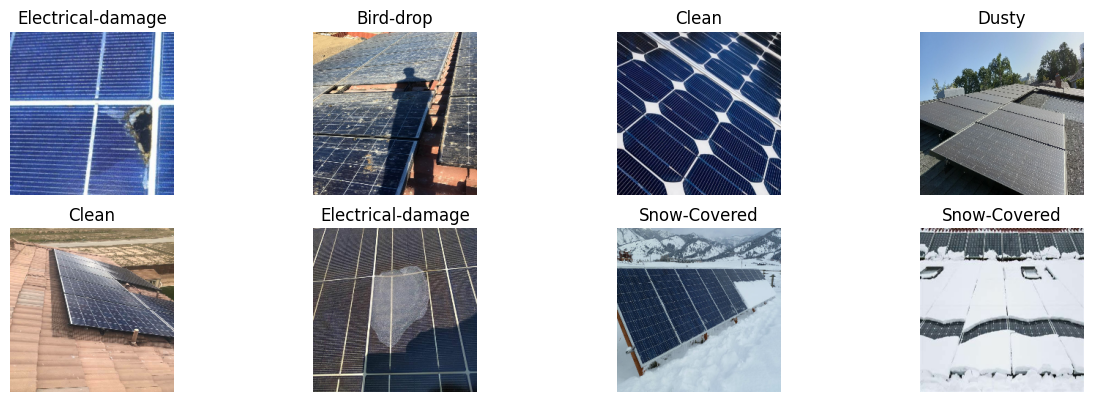

In [5]:
plt.figure(figsize=(15, 20))
for images, labels in train.take(1):
    for i in range(8):
        ax = plt.subplot(8, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
base_model = tf.keras.applications.MobileNetV3Small(input_shape=(224,224,3),include_top=False,weights='imagenet')
base_model.trainable = False
keras_model=keras.models.Sequential()
keras_model.add(base_model)
keras_model.add(keras.layers.Flatten())
keras_model.add(keras.layers.Dropout(0.5))
keras_model.add(keras.layers.Dense(6,activation=tf.nn.softmax))
keras_model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       169,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,470 (4.23 MB)

 Trainable params: 169,350 (661.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

keras_model = keras.models.Sequential([
    keras.layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    base_model,
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation=tf.nn.softmax)
])
keras_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │       376,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,634,310 (10.05 MB)

 Trainable params: 376,326 (1.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
keras_model.build()

In [9]:
checkpoint =ModelCheckpoint("kkeras_model.keras", save_best_only=True)

In [10]:
early_stopping =EarlyStopping(patience=5, restore_best_weights=True)

In [11]:
keras_model.compile(optimizer ='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist=keras_model.fit(train,epochs=25,validation_data=validation,callbacks=[checkpoint,early_stopping])

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 122s 5s/step - accuracy: 0.5551 - loss: 4.4644 - val_accuracy: 0.8136 - val_loss: 1.7182
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.8842 - loss: 0.8216 - val_accuracy: 0.8983 - val_loss: 0.8491
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9407 - loss: 0.4597 - val_accuracy: 0.8531 - val_loss: 1.4533
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9506 - loss: 0.2639 - val_accuracy: 0.9322 - val_loss: 0.8120
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 93s 3s/step - accuracy: 0.9689 - loss: 0.2219 - val_accuracy: 0.9548 - val_loss: 0.6504
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9774 - loss: 0.1950 - val_accuracy: 0.9435 - val_loss: 0.7260
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9887 - loss: 0.0532 - val_accuracy: 0.9435 - val_loss: 0.7393
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9873 - loss: 0.1315 - val_accuracy: 0.9492 - val_loss

In [12]:
hist_=pd.DataFrame(hist.history)
hist_

,accuracy,loss,val_accuracy,val_loss
0,0.555085,4.464437,0.813559,1.718219
1,0.884181,0.821559,0.898305,0.849090
2,0.940678,0.459692,0.853107,1.453276
3,0.950565,0.263901,0.932203,0.812038
4,0.968927,0.221870,0.954802,0.650434
5,0.977401,0.194974,0.943503,0.725985
6,0.988701,0.053201,0.943503,0.739309
7,0.987288,0.131491,0.949153,0.677997
8,0.990113,0.086258,0.949153,0.665824
9,0.994350,0.113133,0.932203,0.822753


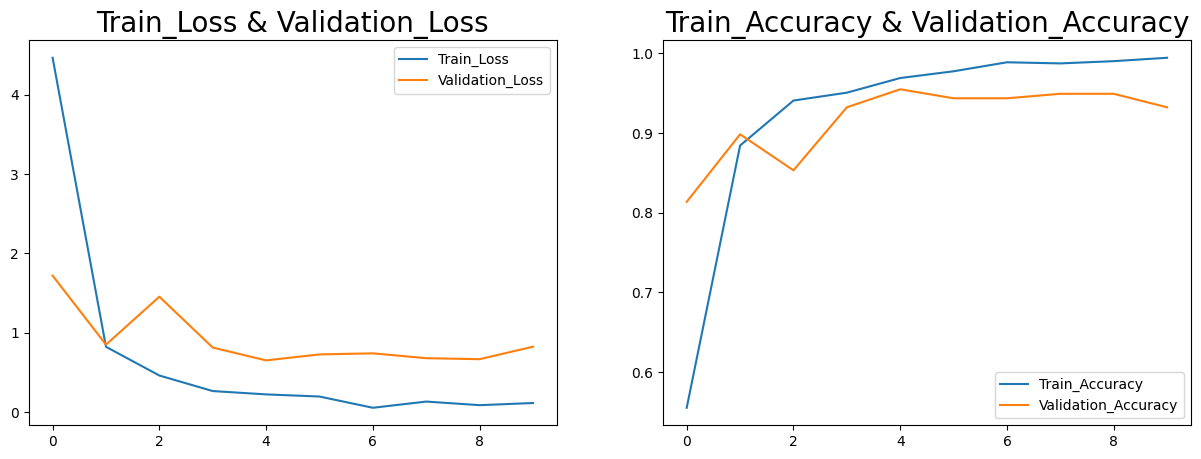

In [13]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()

In [14]:
X_val,y_val,y_pred=[],[],[]
for images, labels in validation:
    y_val.extend(labels.numpy())
    X_val.extend(images.numpy())
predictions=keras_model.predict(np.array(X_val))
for i in predictions:
    y_pred.append(np.argmax(i))
df=pd.DataFrame()
df['Actual'],df['Prediction']=y_val,y_pred
df

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


,Actual,Prediction
0,0,0
1,2,2
2,0,2
3,0,0
4,0,0
...,...,...
172,1,1
173,3,3
174,1,1
175,3,3


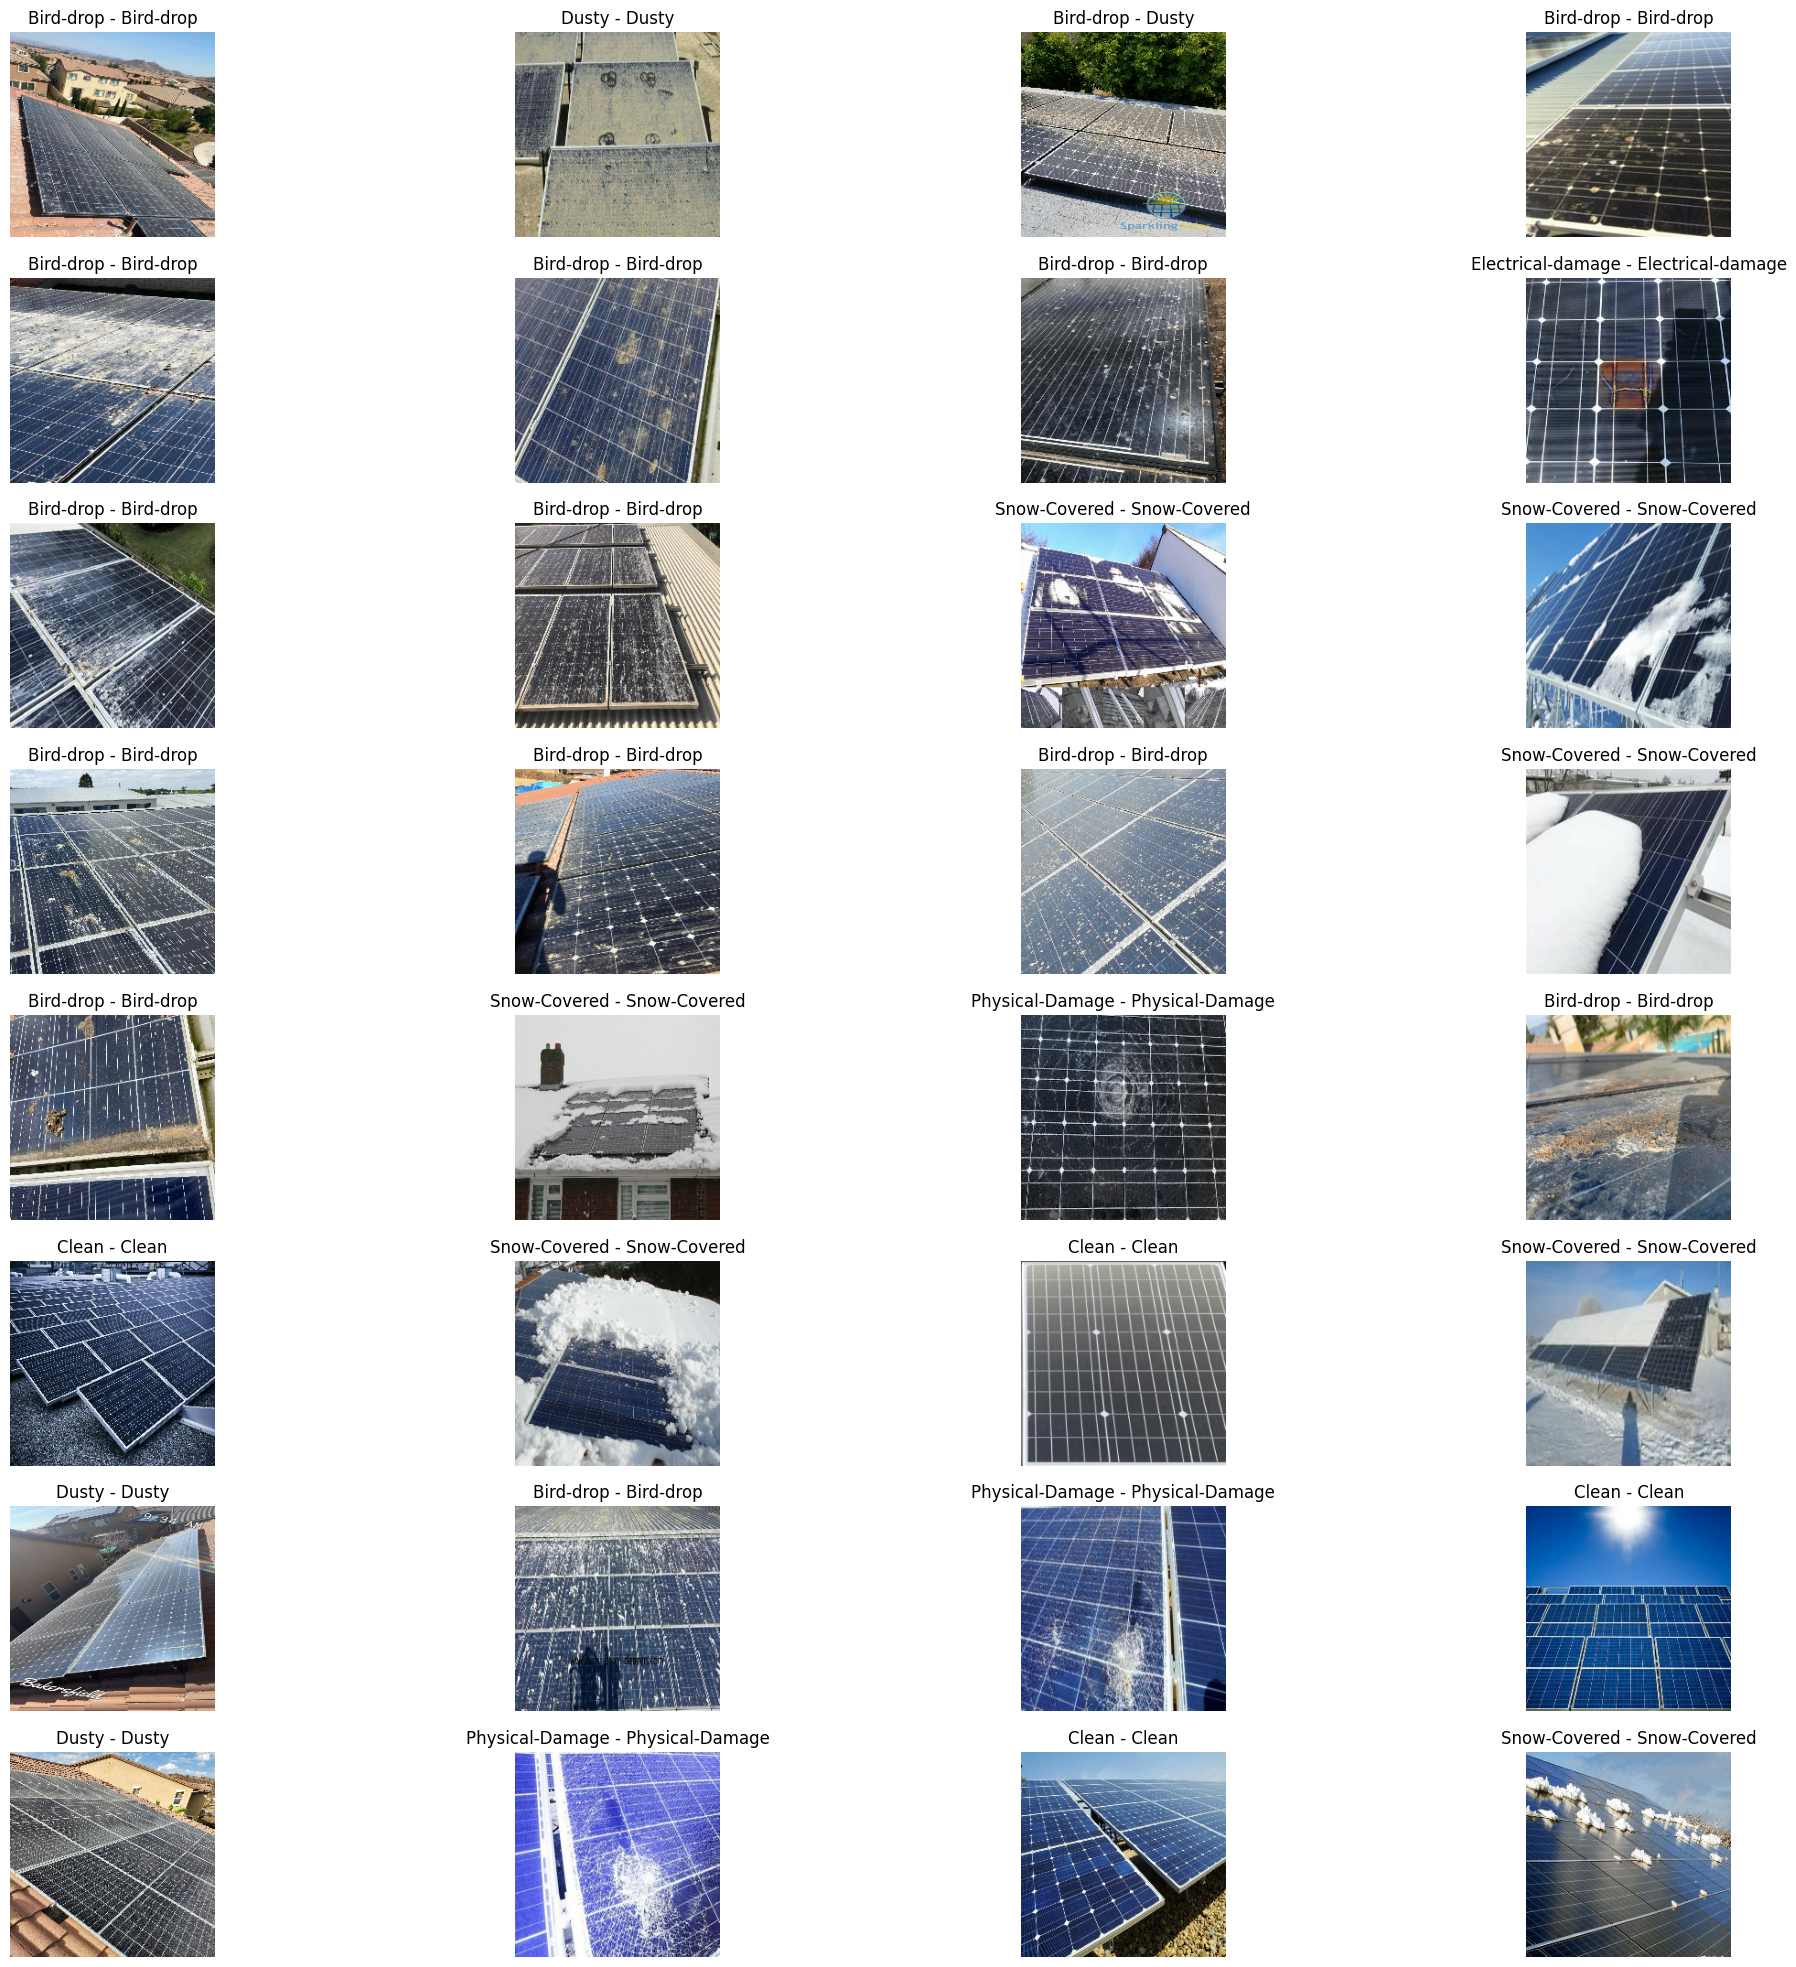

In [15]:
plt.figure(figsize=(25,25))
for i in range(32):
    ax = plt.subplot(8, 4, i + 1)
    plt.imshow(X_val[i].astype("uint8"))
    plt.title(f'{class_names[y_val[i]]} - {class_names[y_pred[i]]}')
    plt.axis("off")

In [16]:
# ── EfficientNetB0 ──────────────────────────────────────────────
eff_base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
eff_base.trainable = False

eff_model = keras.models.Sequential([
    eff_base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
eff_checkpoint = ModelCheckpoint("eff_model.keras", save_best_only=True)
eff_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [18]:
eff_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
eff_hist = eff_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[eff_checkpoint, eff_early_stopping]
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.3234 - loss: 1.6843 - val_accuracy: 0.5876 - val_loss: 1.2530
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.5480 - loss: 1.2200 - val_accuracy: 0.6780 - val_loss: 0.9616
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.6483 - loss: 1.0168 - val_accuracy: 0.7119 - val_loss: 0.8241
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.6808 - loss: 0.9262 - val_accuracy: 0.7232 - val_loss: 0.7383
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.7331 - loss: 0.8013 - val_accuracy: 0.7966 - val_loss: 0.6776
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.7613 - loss: 0.7284 - val_accuracy: 0.7910 - val_loss: 0.6285
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.7740 - loss: 0.6922 - val_accuracy: 0.8192 - val_loss: 0.5970
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.7726 - loss: 0.6833 - val_accuracy: 0.8249 - val_loss:

In [19]:
eff_hist_ = pd.DataFrame(eff_hist.history)
eff_hist_

,accuracy,loss,val_accuracy,val_loss
0,0.323446,1.684309,0.587571,1.252969
1,0.548023,1.219984,0.677966,0.961641
2,0.648305,1.016792,0.711864,0.824068
3,0.680791,0.926198,0.723164,0.738266
4,0.733051,0.801316,0.796610,0.677608
5,0.761299,0.728362,0.790960,0.628461
6,0.774011,0.692185,0.819209,0.596964
7,0.772599,0.683296,0.824859,0.565101
8,0.786723,0.629542,0.836158,0.538290
9,0.793785,0.602836,0.841808,0.515375


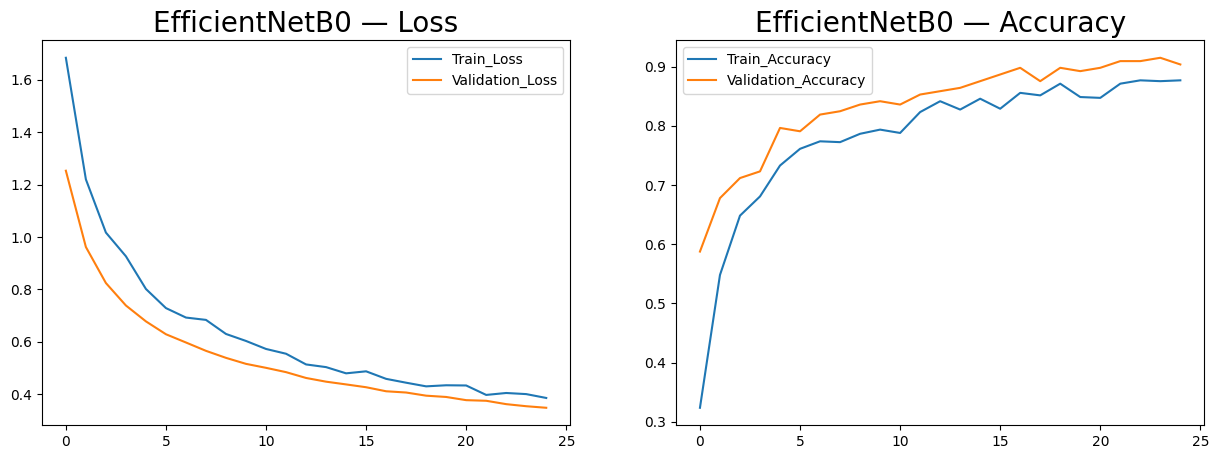

In [20]:

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(eff_hist_['loss'], label='Train_Loss')
plt.plot(eff_hist_['val_loss'], label='Validation_Loss')
plt.title('EfficientNetB0 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eff_hist_['accuracy'], label='Train_Accuracy')
plt.plot(eff_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('EfficientNetB0 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [21]:
eff_y_pred = []
predictions_eff = eff_model.predict(np.array(X_val))  # reuses X_val, y_val from MobileNetV2 section
for i in predictions_eff:
    eff_y_pred.append(np.argmax(i))

print("EfficientNetB0 Accuracy:", accuracy_score(y_val, eff_y_pred))
print(classification_report(y_val, eff_y_pred, target_names=class_names))

6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step
EfficientNetB0 Accuracy: 0.903954802259887
                   precision    recall  f1-score   support

        Bird-drop       0.92      0.94      0.93        48
            Clean       0.92      0.85      0.88        40
            Dusty       0.79      0.79      0.79        29
Electrical-damage       0.90      0.90      0.90        20
  Physical-Damage       1.00      1.00      1.00        13
     Snow-Covered       0.93      1.00      0.96        27

         accuracy                           0.90       177
        macro avg       0.91      0.91      0.91       177
     weighted avg       0.90      0.90      0.90       177



In [22]:
# ── ShuffleNet (fixed for Keras 3 / TF2) ─────────────────────────
def channel_shuffle(x, groups=2):
    return keras.layers.Lambda(
        lambda t: tf.reshape(
            tf.transpose(
                tf.reshape(t, [-1, tf.shape(t)[1], tf.shape(t)[2], groups, tf.shape(t)[3] // groups]),
                perm=[0, 1, 2, 4, 3]
            ),
            [-1, tf.shape(t)[1], tf.shape(t)[2], tf.shape(t)[3]]
        )
    )(x)

def shuffle_unit(x, out_channels, strides, groups=2):
    in_channels = x.shape[-1]
    bottleneck = out_channels // 4

    if strides == 2:
        shortcut = keras.layers.DepthwiseConv2D(
            kernel_size=3, strides=2, padding='same', use_bias=False)(x)
        shortcut = keras.layers.BatchNormalization()(shortcut)
        shortcut = keras.layers.Conv2D(
            out_channels // 2, 1, use_bias=False)(shortcut)
        shortcut = keras.layers.BatchNormalization()(shortcut)
        shortcut = keras.layers.ReLU()(shortcut)
    else:
        shortcut = x

    residual = keras.layers.Conv2D(bottleneck, 1, use_bias=False)(x)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.ReLU()(residual)
    residual = keras.layers.DepthwiseConv2D(
        kernel_size=3, strides=strides, padding='same', use_bias=False)(residual)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.Conv2D(out_channels // 2, 1, use_bias=False)(residual)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.ReLU()(residual)

    if strides == 1:
        c = in_channels // 2
        # Use Lambda for slicing instead of direct indexing
        x1 = keras.layers.Lambda(lambda t: t[:, :, :, :c])(x)
        x2 = keras.layers.Lambda(lambda t: t[:, :, :, c:])(x)
        out = keras.layers.Concatenate()([x2, residual])
    else:
        out = keras.layers.Concatenate()([shortcut, residual])

    out = channel_shuffle(out, groups=2)
    return out

def build_shufflenet(input_shape=(224, 224, 3), num_classes=6):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(24, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    stages = [(116, 4), (232, 8), (464, 4)]
    for out_ch, repeats in stages:
        x = shuffle_unit(x, out_ch, strides=2)
        for _ in range(repeats - 1):
            x = shuffle_unit(x, out_ch, strides=1)

    x = keras.layers.Conv2D(1024, 1, use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.5)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='ShuffleNetV2')

In [23]:
shuffle_model = build_shufflenet(input_shape=(224, 224, 3), num_classes=6)
shuffle_model.summary()

Model: "ShuffleNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        648 │ input_layer_6[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu_14[0][0]    │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │        696 │ max_pooling2d[0]… │
│                     │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        116 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 28, 28,    │        216 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 28, 28,    │        261 │ re_lu_16[0][0]    │
│ (DepthwiseConv2D)   │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         96 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        116 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      1,392 │ batch_normalizat… │
│                     │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │      1,682 │ batch_normalizat… │
│                     │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        232 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        232 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 1,055,650 (4.03 MB)

 Trainable params: 1,043,646 (3.98 MB)

 Non-trainable params: 12,004 (46.89 KB)

In [24]:
shuffle_checkpoint = ModelCheckpoint("shuffle_model.keras", save_best_only=True)
shuffle_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [25]:
shuffle_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
shuffle_hist = shuffle_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[shuffle_checkpoint, shuffle_early_stopping]
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.2500 - loss: 1.8740 - val_accuracy: 0.1525 - val_loss: 1.8527
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.3842 - loss: 1.5295 - val_accuracy: 0.1525 - val_loss: 2.0124
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.4562 - loss: 1.3903 - val_accuracy: 0.1525 - val_loss: 2.2546
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.5254 - loss: 1.2505 - val_accuracy: 0.1525 - val_loss: 2.5535
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.5706 - loss: 1.0970 - val_accuracy: 0.1525 - val_loss: 2.8698
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.6370 - loss: 0.9945 - val_accuracy: 0.1525 - val_loss: 3.4024


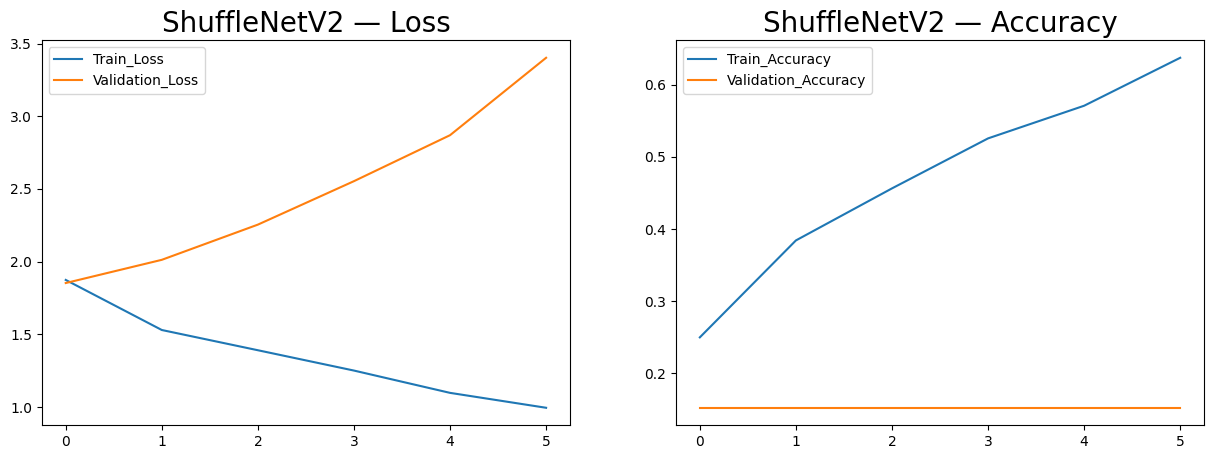

In [26]:
shuffle_hist_ = pd.DataFrame(shuffle_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(shuffle_hist_['loss'], label='Train_Loss')
plt.plot(shuffle_hist_['val_loss'], label='Validation_Loss')
plt.title('ShuffleNetV2 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(shuffle_hist_['accuracy'], label='Train_Accuracy')
plt.plot(shuffle_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('ShuffleNetV2 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [27]:
shuffle_y_pred = []
predictions_shuffle = shuffle_model.predict(np.array(X_val))
for i in predictions_shuffle:
    shuffle_y_pred.append(np.argmax(i))

print("ShuffleNetV2 Accuracy:", accuracy_score(y_val, shuffle_y_pred))
print(classification_report(y_val, shuffle_y_pred, target_names=class_names))

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
ShuffleNetV2 Accuracy: 0.15254237288135594
                   precision    recall  f1-score   support

        Bird-drop       0.00      0.00      0.00        48
            Clean       0.00      0.00      0.00        40
            Dusty       0.00      0.00      0.00        29
Electrical-damage       0.00      0.00      0.00        20
  Physical-Damage       0.00      0.00      0.00        13
     Snow-Covered       0.15      1.00      0.26        27

         accuracy                           0.15       177
        macro avg       0.03      0.17      0.04       177
     weighted avg       0.02      0.15      0.04       177



In [29]:
# ── VGG16 ────────────────────────────────────────────────────────
vgg_base = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
vgg_base.trainable = False

vgg_model = keras.models.Sequential([
    vgg_base,
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [30]:
vgg_checkpoint = ModelCheckpoint("vgg_model.keras", save_best_only=True)
vgg_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [ ]:
vgg_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
vgg_hist = vgg_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[vgg_checkpoint, vgg_early_stopping]
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 535s 23s/step - accuracy: 0.4237 - loss: 24.4870 - val_accuracy: 0.8362 - val_loss: 2.3940
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 527s 23s/step - accuracy: 0.7486 - loss: 3.0227 - val_accuracy: 0.9153 - val_loss: 0.6795
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 531s 23s/step - accuracy: 0.8079 - loss: 0.9293 - val_accuracy: 0.9322 - val_loss: 0.3170
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 528s 23s/step - accuracy: 0.8178 - loss: 0.7956 - val_accuracy: 0.9209 - val_loss: 0.2785
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 483s 21s/step - accuracy: 0.8136 - loss: 0.6034 - val_accuracy: 0.9153 - val_loss: 0.2990
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 527s 23s/step - accuracy: 0.8432 - loss: 0.6905 - val_accuracy: 0.9322 - val_loss: 0.2783
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 481s 21s/step - accuracy: 0.8644 - loss: 0.4749 - val_accuracy: 0.9379 - val_loss: 0.2020
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 523s 23s/step - accuracy: 0.8602 - loss: 0.4417 - val_accuracy: 0

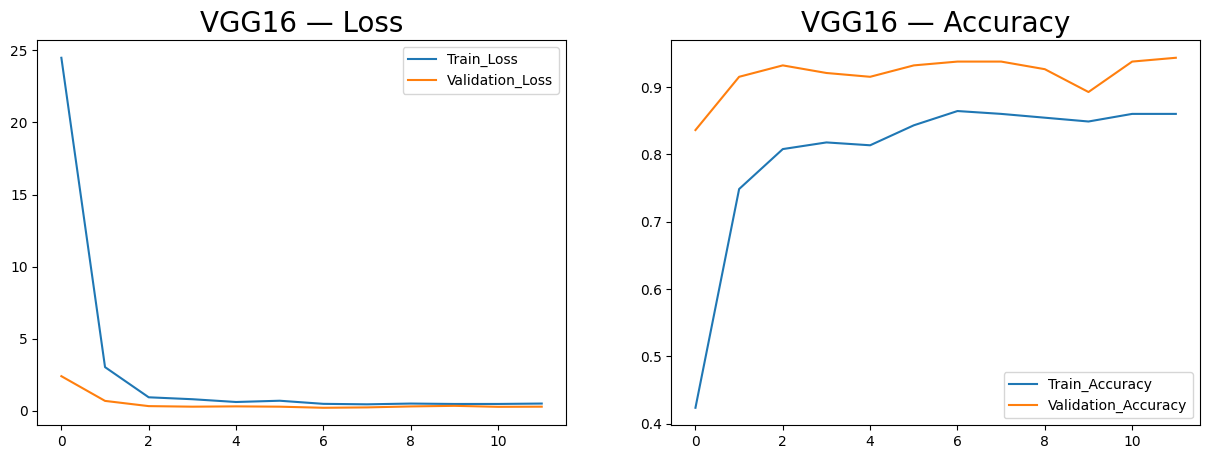

In [33]:
vgg_hist_ = pd.DataFrame(vgg_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(vgg_hist_['loss'], label='Train_Loss')
plt.plot(vgg_hist_['val_loss'], label='Validation_Loss')
plt.title('VGG16 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_hist_['accuracy'], label='Train_Accuracy')
plt.plot(vgg_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('VGG16 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [34]:
vgg_y_pred = []
predictions_vgg = vgg_model.predict(np.array(X_val))
for i in predictions_vgg:
    vgg_y_pred.append(np.argmax(i))

print("VGG16 Accuracy:", accuracy_score(y_val, vgg_y_pred))
print(classification_report(y_val, vgg_y_pred, target_names=class_names))

6/6 ━━━━━━━━━━━━━━━━━━━━ 103s 16s/step
VGG16 Accuracy: 0.9378531073446328
                   precision    recall  f1-score   support

        Bird-drop       0.96      0.94      0.95        48
            Clean       0.89      0.97      0.93        40
            Dusty       0.90      0.90      0.90        29
Electrical-damage       0.95      0.90      0.92        20
  Physical-Damage       1.00      0.85      0.92        13
     Snow-Covered       1.00      1.00      1.00        27

         accuracy                           0.94       177
        macro avg       0.95      0.93      0.94       177
     weighted avg       0.94      0.94      0.94       177



Model                Val Accuracy
MobileNetV2                0.9548
EfficientNetB0             0.9040
ShuffleNetV2               0.1525
VGG16                      0.9379


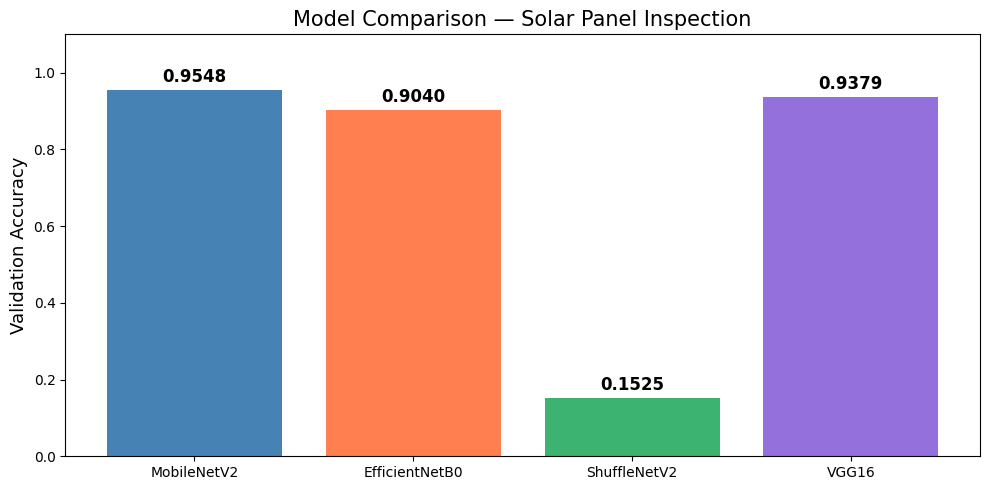

In [35]:
results = {
    'MobileNetV2':    accuracy_score(y_val, y_pred),
    'EfficientNetB0': accuracy_score(y_val, eff_y_pred),
    'ShuffleNetV2':   accuracy_score(y_val, shuffle_y_pred),
    'VGG16':          accuracy_score(y_val, vgg_y_pred),
}

print("=" * 42)
print(f"{'Model':<20} {'Val Accuracy':>12}")
print("=" * 42)
for model_name, acc in results.items():
    print(f"{model_name:<20} {acc:>12.4f}")
print("=" * 42)

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
plt.figure(figsize=(10, 5))
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.ylim(0, 1.1)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.title('Model Comparison — Solar Panel Inspection', fontsize=15)
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02,
             f"{acc:.4f}", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

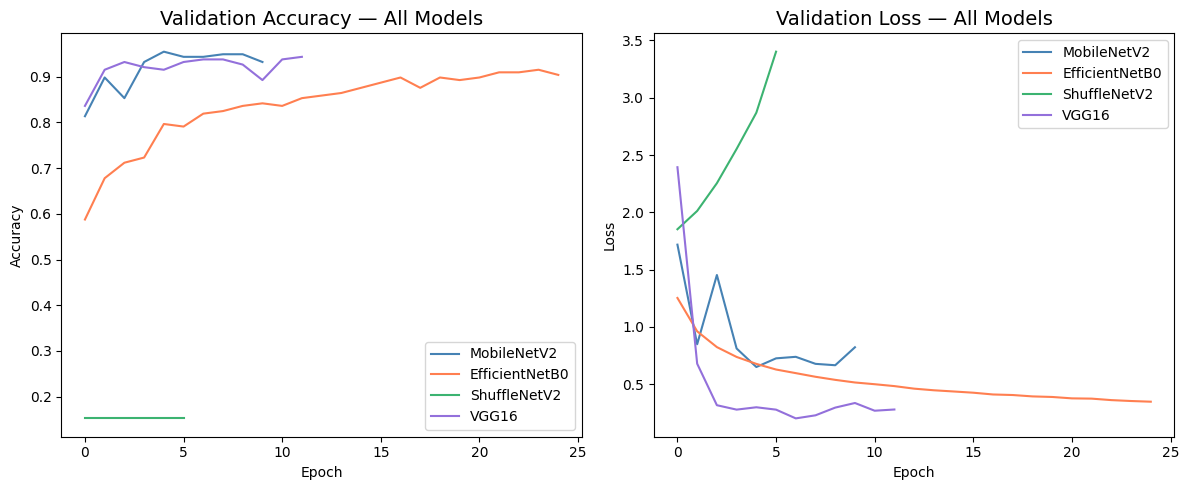

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_['val_accuracy'],         label='MobileNetV2',    color='steelblue')
plt.plot(eff_hist_['val_accuracy'],     label='EfficientNetB0', color='coral')
plt.plot(shuffle_hist_['val_accuracy'], label='ShuffleNetV2',   color='mediumseagreen')
plt.plot(vgg_hist_['val_accuracy'],     label='VGG16',          color='mediumpurple')
plt.title('Validation Accuracy — All Models', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_['val_loss'],         label='MobileNetV2',    color='steelblue')
plt.plot(eff_hist_['val_loss'],     label='EfficientNetB0', color='coral')
plt.plot(shuffle_hist_['val_loss'], label='ShuffleNetV2',   color='mediumseagreen')
plt.plot(vgg_hist_['val_loss'],     label='VGG16',          color='mediumpurple')
plt.title('Validation Loss — All Models', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
summary_data = {
    'Model':         ['MobileNetV2', 'EfficientNetB0', 'ShuffleNetV2', 'VGG16'],
    'Val Accuracy':  [
        round(accuracy_score(y_val, y_pred), 4),
        round(accuracy_score(y_val, eff_y_pred), 4),
        round(accuracy_score(y_val, shuffle_y_pred), 4),
        round(accuracy_score(y_val, vgg_y_pred), 4),
    ],
    'Trainable Params': [
        keras_model.count_params(),
        eff_model.count_params(),
        shuffle_model.count_params(),
        vgg_model.count_params(),
    ],
    'Type': ['Lightweight', 'Lightweight', 'Lightweight', 'Heavyweight']
}

summary_df = pd.DataFrame(summary_data).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
summary_df

,Model,Val Accuracy,Trainable Params,Type
0,MobileNetV2,0.9548,2634310,Lightweight
1,VGG16,0.9379,21139014,Heavyweight
2,EfficientNetB0,0.9040,4057257,Lightweight
3,ShuffleNetV2,0.1525,1055650,Lightweight
